In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


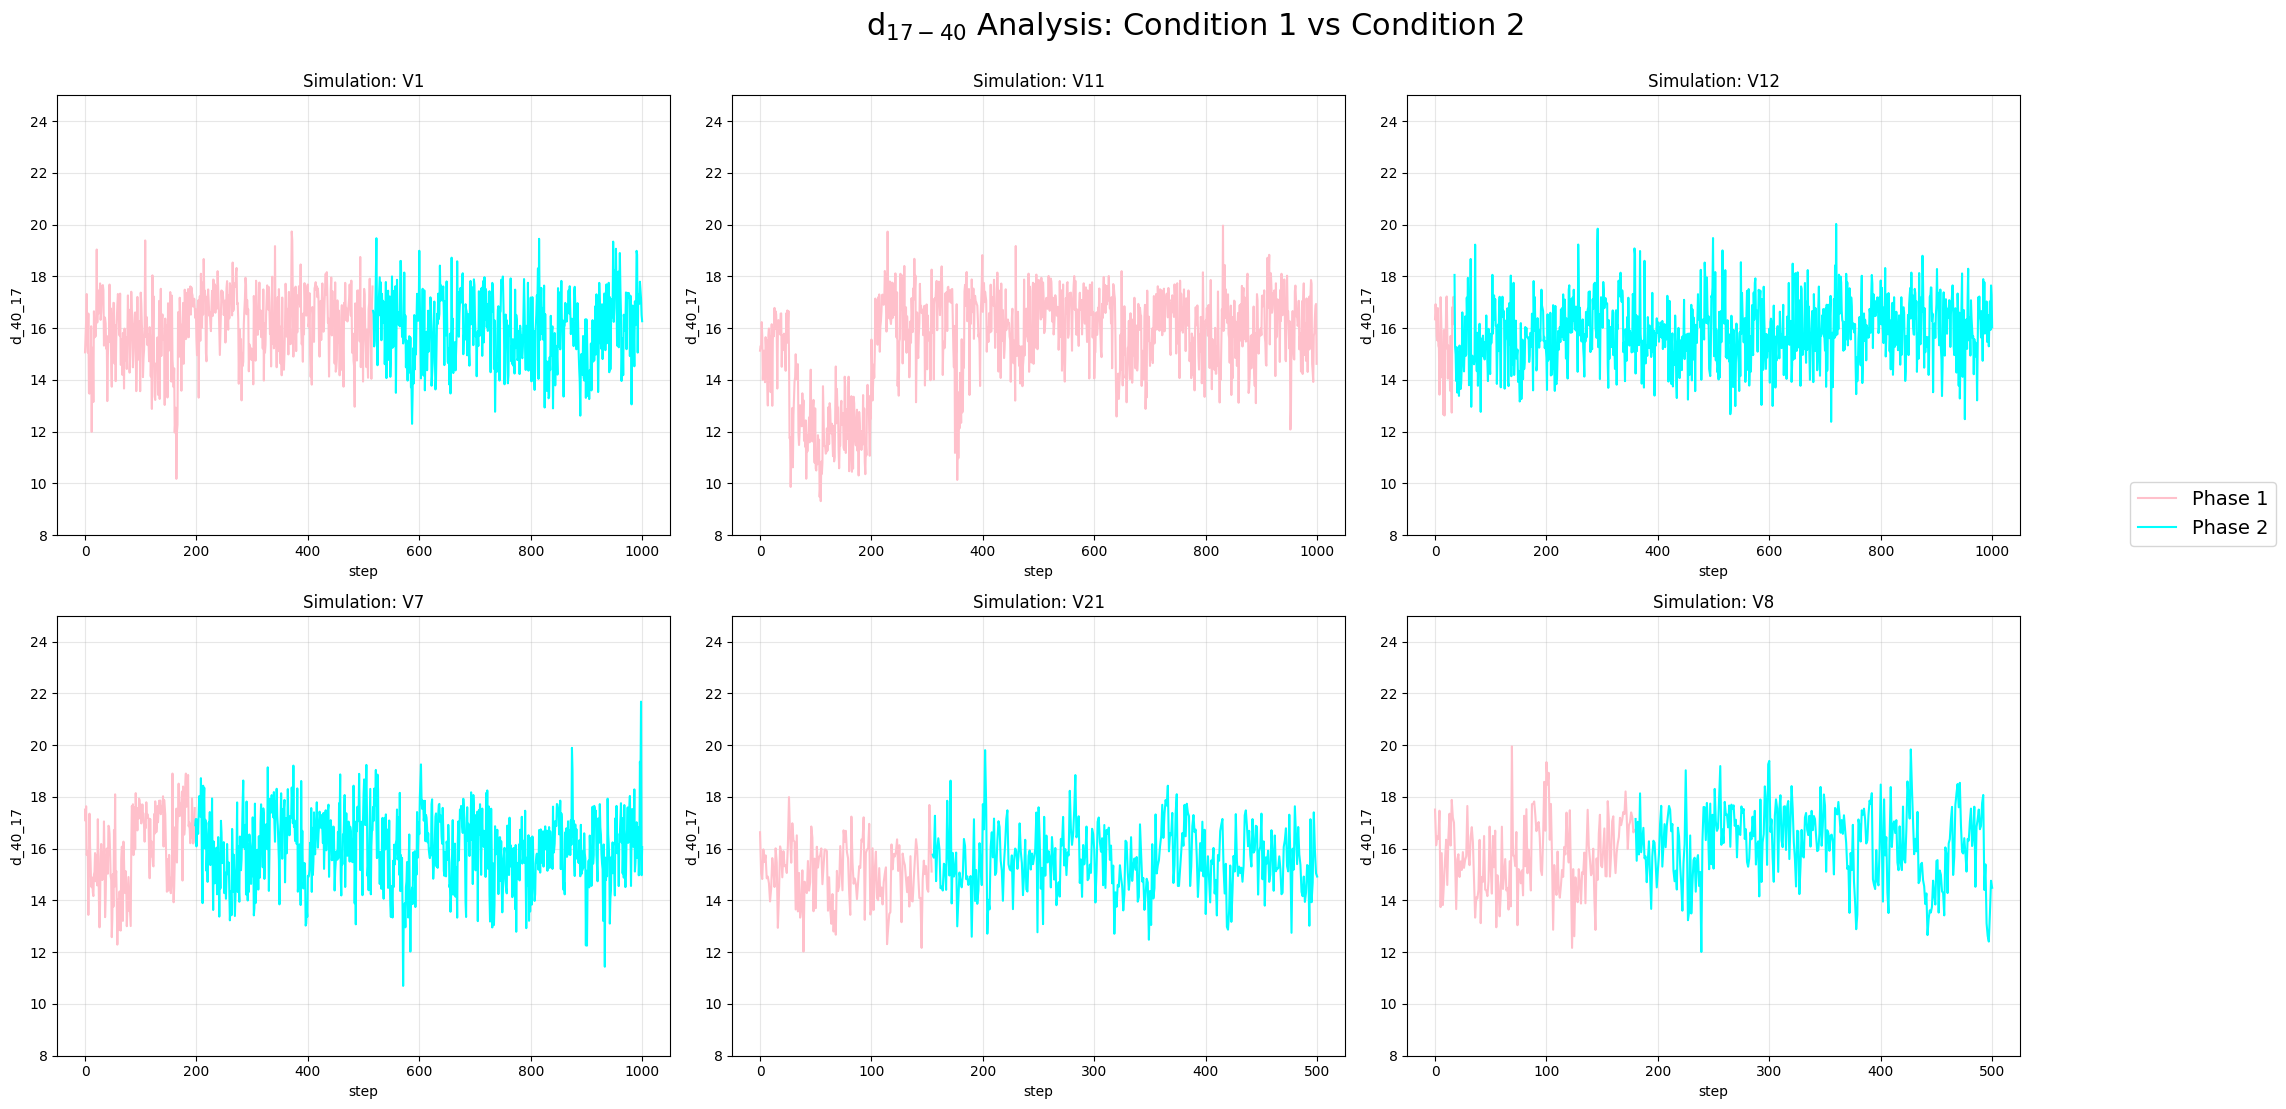

In [12]:
# Code to calculate d_40_17 distance throughout the MD simulation run
# d-40_17 is a metric that evaluates the distance between two ASP40 and ASP17 residues on chain A and chain B
# Here, for chain A it will be ASP_40, for chain B it will be ASP_17 (chB starts from 100th residue
# d_40_17 will is found in the distance file in col 40_17
# to calculate d_40_17 the cal_d_40_17 function is changed:
    #d_40_17(chain A): distance_df["17_40"]
    #d_40-17(chain B): distance_df["116_139"]
# The calculated values are used to create plots with matplotlib, and generate statistics csv file



#IMPORTS

import os
import pandas as pd
import matplotlib.pyplot as plt
import math

#SETUP
rootdir = '/content/drive/MyDrive/M1_STAGE/Data/simulations_1HSI/'
os.chdir(rootdir)

#FUNCTIONS

# a. Distance (d_40_17) calculation
def cal_d_40_17 (distance_df):
    d_40_17 = distance_df["116_139"]
    return d_40_17

#MAIN

# 1. fetch all distance files
#store all file paths
distance_files_paths = []

for subdir, dirs, files in os.walk(rootdir):
    for file in files:
        if file.startswith("distance_"):
	        distance_files_paths.append(os.path.join(subdir, file))
            
# Determine grid size for subplots
num_files = len(distance_files_paths)
# Adjust ncols and nrows to create a somewhat square grid
num_cols = min(num_files, 3)
num_rows = math.ceil(num_files / num_cols)

phase_limit_dico = {
    'V7': 198,
    'V8': 180,
    'V21': 155,
    'V12': 35,
    'V11': 1000,
    'V1': 517,
}

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 8, num_rows * 6), squeeze=False)
axes = axes.flatten()
fig.suptitle("d$_{17-40}$ Analysis: Condition 1 vs Condition 2", fontsize=22, y=0.92)
plot_idx = 0
line_c1 = None
line_c2 = None

# 2. iterate on each distance file
# 2.1 create pd DF for each distance file
for i, distance_file in enumerate(distance_files_paths):
    ax = axes[plot_idx]

    #transform into pd dataframe
    distance_df = pd.read_csv(distance_file)
    #transform GROMACS distances in nm to Angstrom (1 nm = 10 A)
    distance_df = distance_df * 10
    distance_df.index.names = ['step']

    # 2.2 compute d_40_17 for each distance file
    time_d_40_17 = cal_d_40_17(distance_df)
    time_d_40_17_df = pd.DataFrame(time_d_40_17)
    time_d_40_17_df.columns.values[0] = "d_40_17"

    #plot on the current subplot
    #to do: change the phase borders for each simulation accordingly
    simulation_name = os.path.basename(os.path.normpath(distance_file)).replace("distance_", "").replace(".csv", "")

    if simulation_name in phase_limit_dico:
        phase_limit = phase_limit_dico[simulation_name]
    line_c1, = ax.plot(time_d_40_17_df.index[:phase_limit], time_d_40_17_df['d_40_17'][:phase_limit], color='pink', linewidth=1.5)
    line_c2, = ax.plot(time_d_40_17_df.index[phase_limit:], time_d_40_17_df['d_40_17'][phase_limit:], color='cyan', linewidth=1.5)

    ax.set_title(f"Simulation: {simulation_name}")
    ax.set_xlabel('step')
    ax.set_ylabel('d_40_17')
    ax.grid(True, alpha=0.3) # Add a grid to the plot
    ax.set_ylim(8,25)
    plot_idx += 1


# hide any unused subplots
for j in range(plot_idx + 1, len(axes)):
    fig.delaxes(axes[j])

# legend
fig.legend(handles=[line_c1, line_c2],     # The line objects
            labels=["Phase 1", "Phase 2"],   # The labels for each line
            loc="center",  # Position of legend
            bbox_to_anchor=(0.92, 0.5),    # Small spacing around legend box
            title_fontsize='18',
            fontsize='14',
            frameon=True
            )
plt.tight_layout(rect=[0, 0, 0.85, 0.92])
plt.show()
#save plot
fig.savefig("../../Manips/Figures/d_40_17.png", bbox_inches='tight', dpi=300)




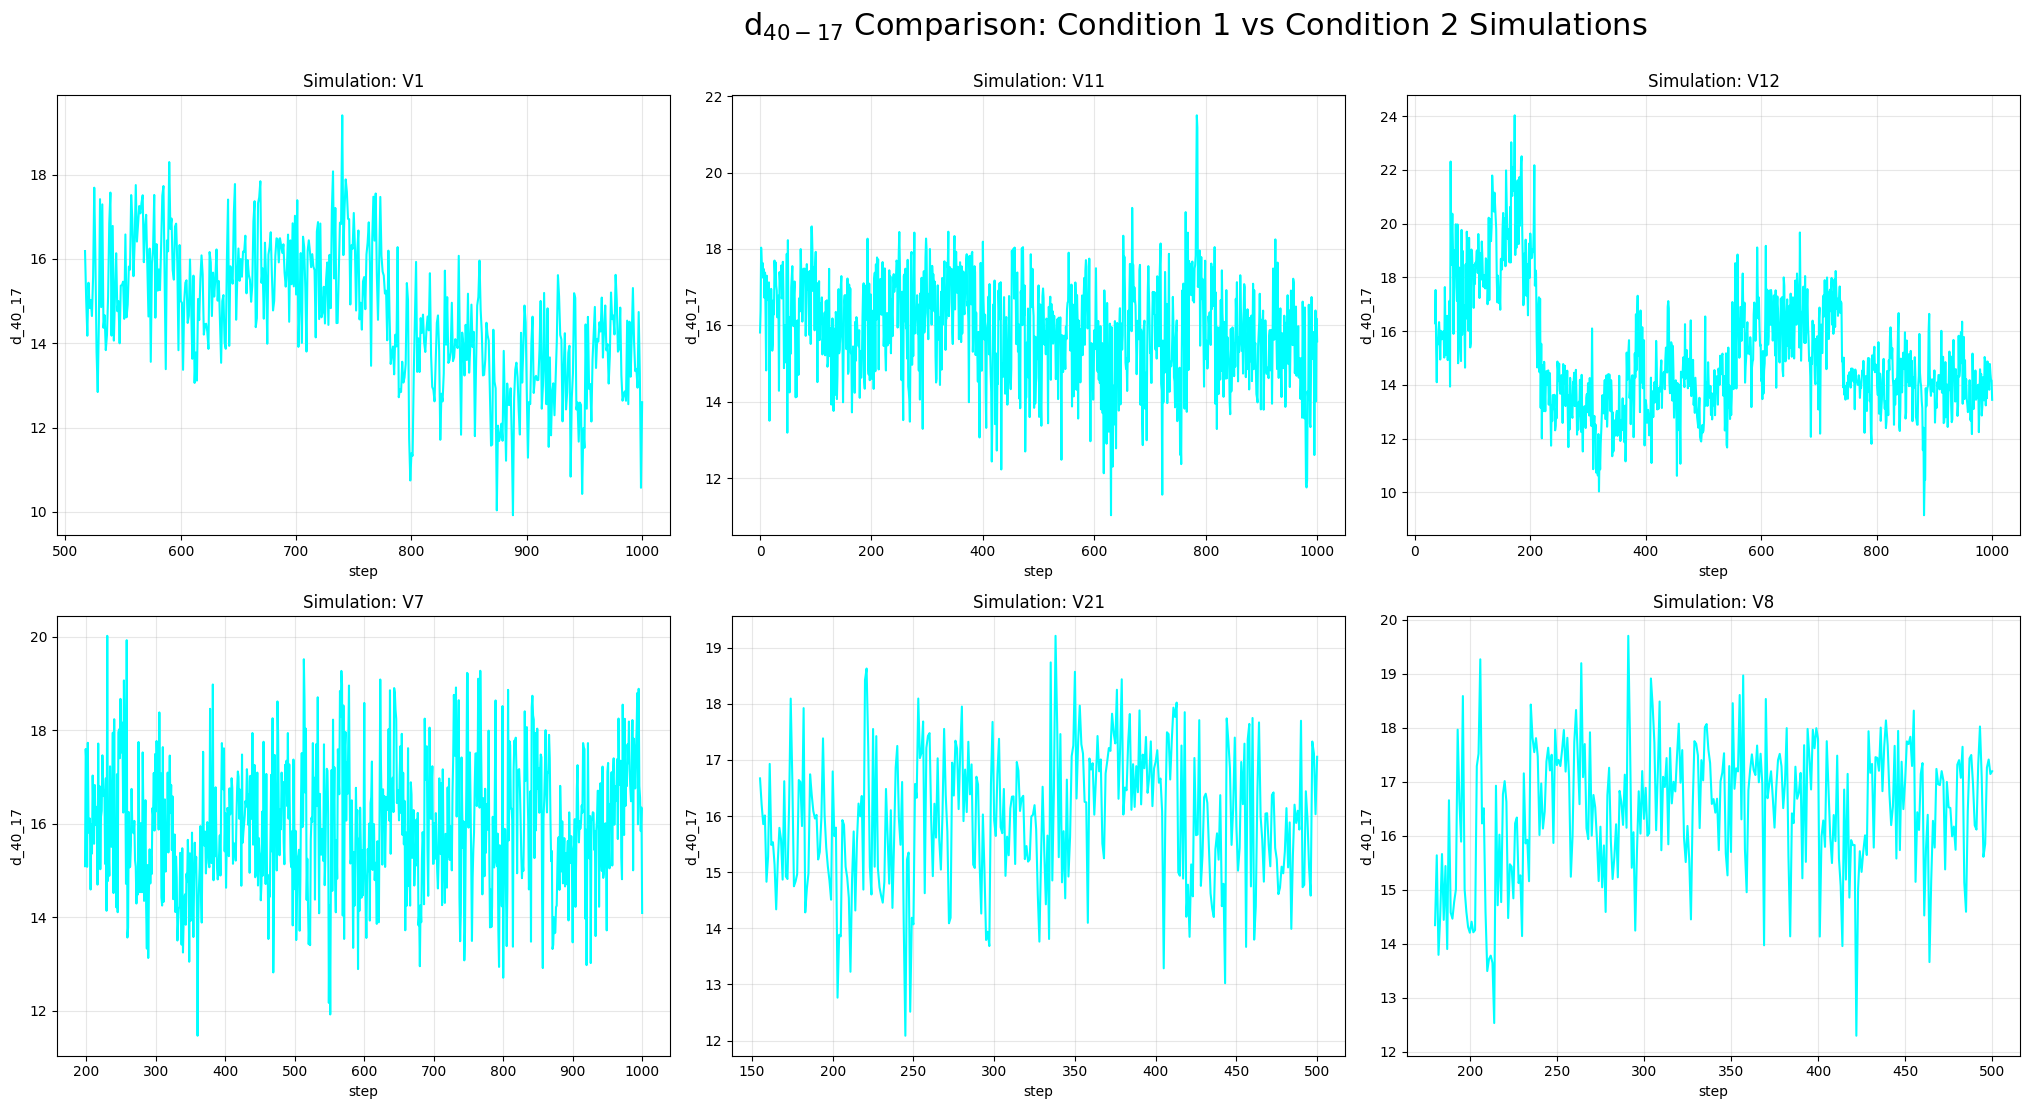

In [ ]:

#Zoomed plot

# Determine grid size for subplots
num_files = len(distance_files_paths)
# Adjust ncols and nrows to create a somewhat square grid
num_cols = min(num_files, 3)
num_rows = math.ceil(num_files / num_cols)

phase_limit_dico = {
    'V7': 198,
    'V8': 180,
    'V21': 155,
    'V12': 35,
    'V11': 0,
    'V1': 517,
}

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 8, num_rows * 6), squeeze=False)
axes = axes.flatten()
fig.suptitle("d$_{17-40}$ Comparison: Condition 1 vs Condition 2 Simulations", fontsize=22, y=0.92)
plot_idx = 0

# 2. iterate on each distance file
# 2.1 create pd DF for each distance file
for i, distance_file in enumerate(distance_files_paths):
    ax = axes[plot_idx]

    #transform into pd dataframe
    distance_df = pd.read_csv(distance_file)
    #transform GROMACS distances in nm to Angstrom (1 nm = 10 A)
    distance_df = distance_df * 10
    distance_df.index.names = ['step']

    # 2.2 compute d_40_17 for each distance file
    time_d_40_17 = cal_d_40_17(distance_df)
    time_d_40_17_df = pd.DataFrame(time_d_40_17)
    time_d_40_17_df.columns.values[0] = "d_40_17"

    #plot on the current subplot
    #to do: change the phase borders for each simulation accordingly
    simulation_name = os.path.basename(os.path.normpath(distance_file)).replace("distance_", "").replace(".csv", "")

    if simulation_name in phase_limit_dico:
        phase_limit = phase_limit_dico[simulation_name]
    ax.plot(time_d_40_17_df.index[phase_limit:], time_d_40_17_df['d_40_17'][phase_limit:], color='cyan', linewidth=1.5)

    ax.set_title(f"Simulation: {simulation_name}")
    ax.set_xlabel('step')
    ax.set_ylabel('d_40_17')
    ax.grid(True, alpha=0.3) # Add a grid to the plot
    plot_idx += 1


# hide any unused subplots
for j in range(plot_idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 0.85, 0.92])
plt.show()
#save plot
fig.savefig("../../Manips/Figures/d_40_17_zoomed.png", bbox_inches='tight', dpi=300)

#calculate the statistics
summary_stats_dict = {} # dico to store loop results

for i, distance_file in enumerate(distance_files_paths):
    # get simulation name from filename
    simulation_name = os.path.basename(os.path.normpath(distance_file)).replace("distance_", "").replace(".csv", "")

    #transform into pd dataframe
    distance_df = pd.read_csv(distance_file)
    #transform GROMACS distances in nm to Angstrom (1 nm = 10 A)
    distance_df = distance_df * 10
    distance_df.index.names = ['step']

    # 2.2 compute d_40_17 for each distance file
    time_d_40_17 = cal_d_40_17(distance_df)
    time_d_40_17_df = pd.DataFrame(time_d_40_17)
    time_d_40_17_df.columns.values[0] = "d_40_17"
    # 2.3. store the result into stat dico
    summary_stats_dict[simulation_name] = time_d_40_17_df['d_40_17'].describe()

summary_stats_df = pd.DataFrame(summary_stats_dict)


# write csv
summary_stats_df.to_csv('../../Manips/Tables/d_40_17_stats.csv', index=True, header=True, decimal=".", float_format="%.3f")